In [2]:
# ── CONFIGURE THIS ──────────────────────────────────────────────────────────
BASE_URL = "http://154.57.164.76:32042"   # <-- paste your instance IP:port
# ────────────────────────────────────────────────────────────────────────────

import os, io, base64, numpy as np, requests, torch, torch.nn as nn
import torch.nn.functional as F
from PIL import Image

MNIST_MEAN, MNIST_STD = 0.1307, 0.3081

def x01_from_b64_png(b64: str) -> np.ndarray:
    """Convert base64 PNG to [0,1] numpy array."""
    raw = base64.b64decode(b64)
    img = Image.open(io.BytesIO(raw)).convert("L")
    if img.size != (28, 28):
        raise ValueError("Expected 28x28 PNG")
    x = np.asarray(img, dtype=np.float32) / 255.0
    return np.clip(x, 0.0, 1.0)

def b64_png_from_x01(x2d: np.ndarray) -> str:
    """Convert [0,1] array to base64 PNG."""
    x255 = np.clip((x2d * 255.0).round(), 0, 255).astype(np.uint8)
    img = Image.fromarray(x255, mode="L")
    buf = io.BytesIO()
    img.save(buf, format="PNG", optimize=True)
    return base64.b64encode(buf.getvalue()).decode("ascii")

def linf(a: np.ndarray, b: np.ndarray) -> float:
    """Compute L_inf distance between two arrays."""
    return float(np.max(np.abs(a - b)))

print("Helpers loaded.")

Helpers loaded.


In [3]:
# ── Fetch challenge and check clean prediction ────────────────────────────────
ch  = requests.get(f"{BASE_URL}/challenge", timeout=10).json()
x   = x01_from_b64_png(ch["image_b64"])      # (28, 28)
lab = int(ch["label"])                        # baseline label
eps = float(ch["epsilon"])                    # numeric bound
res = requests.post(f"{BASE_URL}/predict",
                    json={"image_b64": b64_png_from_x01(x)},
                    timeout=10).json()
print({"baseline_label": lab, "server_pred": res["pred"], "epsilon": eps})

{'baseline_label': 1, 'server_pred': 1, 'epsilon': 0.25}


In [4]:
# ── Model architecture ────────────────────────────────────────────────────────
class SimpleClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1    = nn.Conv2d(1, 32, 3, 1)
        self.conv2    = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1      = nn.Linear(9216, 128)
        self.fc2      = nn.Linear(128, 10)

    def forward(self, x01: torch.Tensor) -> torch.Tensor:
        """Forward pass with internal normalization.
        Args:
            x01: Input tensor in [0,1] with shape (N, 1, 28, 28)
        Returns:
            Log-probabilities with shape (N, 10)
        """
        x = (x01 - MNIST_MEAN) / MNIST_STD
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return torch.log_softmax(x, dim=1)

# Download and load weights
wt = requests.get(f"{BASE_URL}/weights", timeout=10).content
open("fgsm_weights.pth", "wb").write(wt)

model = SimpleClassifier().eval()
state = torch.load("fgsm_weights.pth", map_location=torch.device("cpu"))
model.load_state_dict(state)

# Verify model works locally
x_tensor   = torch.from_numpy(x[None, None, ...]).float()
logits     = model(x_tensor)
local_pred = int(torch.argmax(logits, dim=1).item())
print(f"Local prediction: {local_pred}, should match server: {res['pred']}")

Local prediction: 1, should match server: 1


In [5]:
# ── Test server validation (expect 400 Not misclassified) ─────────────────────
bad = requests.post(f"{BASE_URL}/submit",
                    json={"image_b64": b64_png_from_x01(x)},
                    timeout=10)
print(bad.status_code, bad.text)  # expected: 400 with "Not misclassified"

400 {"detail":"Not misclassified; try a stronger perturbation"}


In [6]:
####################################################################################################
# RUNS MODEL IN SAFE EVALUATION MODE AND COMPUTES PREDICTION AND LOSS NEEDED FOR ADVERSARIAL GRADIENT
####################################################################################################

def _forward_and_loss(model: nn.Module, x: torch.Tensor, y: torch.Tensor):
    """Forward pass and cross-entropy loss without side effects.

    Args:
        model: Neural network classifier
        x: Input images tensor
        y: Target labels tensor

    Returns:
        tuple[Tensor, Tensor]: Model logits and scalar loss value
    """
    if getattr(model, "training", False):
        raise RuntimeError("Expected model.eval() for attack computations")
    logits = model(x)
    loss   = F.cross_entropy(logits, y)
    return logits, loss

In [7]:
#####################################################
# CALCULATES GRADIENT OF LOSS WITH RESPECT TO AN IMAGE
#####################################################

def _input_gradient(model: nn.Module, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """Return gradient of loss with respect to input tensor x.

    Args:
        model: Neural network in evaluation mode
        x: Input images to compute gradients for
        y: True labels for loss computation

    Returns:
        Tensor: Gradient tensor with same shape as x
    """
    x_req = x.clone().detach().requires_grad_(True)
    _, loss = _forward_and_loss(model, x_req, y)
    model.zero_grad(set_to_none=True)
    loss.backward()
    return x_req.grad.detach()

In [8]:
def iterative_fgsm(model: nn.Module,
                   images: torch.Tensor,
                   labels: torch.Tensor,
                   epsilon: float,
                   num_iter: int,
                   alpha: float | None = None,
                   targeted: bool = False,
                   random_start: bool = False) -> torch.Tensor:
    """Iterative FGSM (Basic Iterative Method) with projection.
    Operates in [0,1] pixel space (model normalises internally).

    Args:
        model: Target classifier in evaluation mode
        images: Clean images in [0,1], shape (N,1,28,28)
        labels: Ground-truth or target labels
        epsilon: L_infinity budget in [0,1] pixel space
        num_iter: Number of iterations
        alpha: Step size per iteration (defaults to epsilon/T)
        targeted: If True, targeted attack
        random_start: If True, initialise within the epsilon ball

    Returns:
        Tensor: Adversarial images in [0,1]
    """
    if alpha is None:
        alpha = epsilon / max(num_iter, 1)

    if random_start:
        torch.manual_seed(1337)
        delta = torch.empty_like(images).uniform_(-epsilon, epsilon)
        x_adv = torch.clamp(images + delta, 0.0, 1.0)
    else:
        x_adv = images.clone()

    for _ in range(num_iter):
        x_adv      = x_adv.detach().requires_grad_(True)
        logits     = model(x_adv)
        loss       = F.cross_entropy(logits, labels)
        model.zero_grad(set_to_none=True)
        loss.backward()
        step_dir   = -1.0 if targeted else 1.0
        x_adv      = x_adv + step_dir * alpha * x_adv.grad.sign()
        # Project onto L∞ ball around original, then clamp to [0,1]
        x_adv      = torch.clamp(images + (x_adv - images).clamp(-epsilon, epsilon), 0.0, 1.0)

    return x_adv.detach()

In [9]:
# ── Run the attack ────────────────────────────────────────────────────────────
# We use a slightly reduced effective epsilon to survive PNG uint8 quantisation.
# PNG round-trip: float -> round(x*255)/255 can shift values by up to 0.5/255.
# Using eps - 1/255 as the attack budget guarantees the server check passes.
SAFE_EPS = eps - 1.0 / 255.0          # ← only change from vanilla iterative_fgsm

x_tensor = torch.from_numpy(x[None, None, ...]).float()          # (1,1,28,28)
y_tensor = torch.tensor([lab], dtype=torch.long)

x_adv_tensor = iterative_fgsm(
    model, x_tensor, y_tensor,
    epsilon=SAFE_EPS,
    num_iter=40,
    alpha=SAFE_EPS / 40,
    targeted=False,
    random_start=True
)

x_adv = x_adv_tensor.squeeze().numpy()   # (28,28)

# Local checks
with torch.no_grad():
    adv_pred_local = int(torch.argmax(model(x_adv_tensor), dim=1).item())

print(f"Clean label       : {lab}")
print(f"Local adv pred    : {adv_pred_local}  (misclassified={adv_pred_local != lab})")
print(f"L∞ (float)        : {linf(x_adv, x):.6f}  ≤ ε={eps}  →  {linf(x_adv, x) <= eps}")

# Simulate the round-trip to PNG and back, then check L∞
x_adv_rt  = x01_from_b64_png(b64_png_from_x01(x_adv))   # round-tripped
linf_rt   = linf(x_adv_rt, x)
print(f"L∞ after PNG round-trip: {linf_rt:.6f}  ≤ ε={eps}  →  {linf_rt <= eps}")

Clean label       : 1
Local adv pred    : 4  (misclassified=True)
L∞ (float)        : 0.246078  ≤ ε=0.25  →  True
L∞ after PNG round-trip: 0.247059  ≤ ε=0.25  →  True


In [10]:
# ── If still not misclassified after round-trip, try more iterations ──────────
# Uncomment if needed:

# x_adv_tensor = iterative_fgsm(
#     model, x_tensor, y_tensor,
#     epsilon=SAFE_EPS, num_iter=100, alpha=SAFE_EPS/50,
#     targeted=False, random_start=True
# )
# x_adv    = x_adv_tensor.squeeze().numpy()
# x_adv_rt = x01_from_b64_png(b64_png_from_x01(x_adv))
# with torch.no_grad():
#     adv_pred_local = int(torch.argmax(model(x_adv_tensor), dim=1).item())
# print(f"adv pred: {adv_pred_local}  |  L∞ rt: {linf(x_adv_rt, x):.6f}")

In [11]:
# ── Validate on server (predict endpoint, no flag yet) ────────────────────────
r_pred = requests.post(f"{BASE_URL}/predict",
                       json={"image_b64": b64_png_from_x01(x_adv)},
                       timeout=10).json()
print(f"Server pred on adversarial image: {r_pred}")
print(f"Misclassified by server: {r_pred['pred'] != lab}")

Server pred on adversarial image: {'pred': 4, 'confidence': 0.9999995231628418}
Misclassified by server: True


In [12]:
# ── Submit for flag ───────────────────────────────────────────────────────────
r_submit = requests.post(f"{BASE_URL}/submit",
                         json={"image_b64": b64_png_from_x01(x_adv)},
                         timeout=10)
print(f"Status: {r_submit.status_code}")
print(r_submit.json())

Status: 200
{'ok': True, 'flag': 'HTB{f457_gr4d13n7_516n_m15l34d5_mn157}', 'pred': 4, 'linf': 0.24705883860588074}


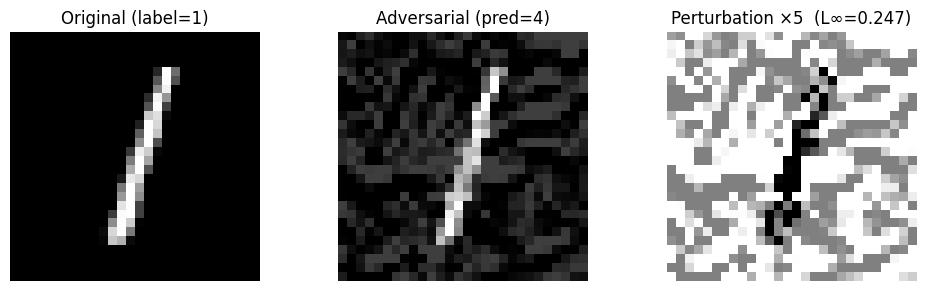

In [13]:
# ── Visualise original vs adversarial ─────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(x, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Original (label={lab})")
axes[1].imshow(x_adv, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Adversarial (pred={adv_pred_local})")
pert = x_adv - x
axes[2].imshow((pert * 5 + 0.5).clip(0, 1), cmap="gray", vmin=0, vmax=1)
axes[2].set_title(f"Perturbation ×5  (L∞={linf(x_adv_rt, x):.3f})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()